# 使用 Slingshot 进行轨迹推断

这里以胰腺内分泌发育数据为例，演示 Slingshot 的 lineage 拟合、伪时间可视化，以及带 lineage 信息的动态趋势总结。

## 方法背景

参考 [Bioconductor 的 Slingshot vignette](https://bioconductor.org/packages/release/bioc/vignettes/slingshot/inst/doc/vignette.html) 和原始 [BMC Genomics 论文](https://bmcgenomics.biomedcentral.com/articles/10.1186/s12864-018-4772-0)，Slingshot 将 cluster 拓扑和光滑曲线拟合结合起来进行轨迹推断。

它的核心思路可以概括为：

- 先在低维空间中对细胞进行聚类
- 用 minimum spanning tree 连接 cluster，恢复全局 lineage 结构
- 在这些 cluster 上拟合 simultaneous principal curves
- 为每条 lineage 计算 lineage-specific pseudotime，同时允许多个 lineage 共享早期主干

这种设计很适合“在 cluster 层面更容易解释拓扑结构”的发育体系。

## 为什么这里使用胰腺数据？

胰腺数据具有紧凑而清晰的分支结构，既有明显的 endocrine 主干，也有多个终末细胞状态，因此很适合展示 Slingshot 的 lineage 拟合和后续的 lineage-aware 动态趋势总结。

## 数据预处理

这里我们以胰腺发育数据为例演示轨迹推断。


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-25 11:23:20] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.57 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.2924s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (4.13s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 4.134s                                                  │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


我们先查看各个主成分对总方差的贡献。这一步可以帮助判断后续构建细胞邻接关系时需要使用多少个 PC。实际分析中，通常只需要一个大致合理的 PC 数即可。

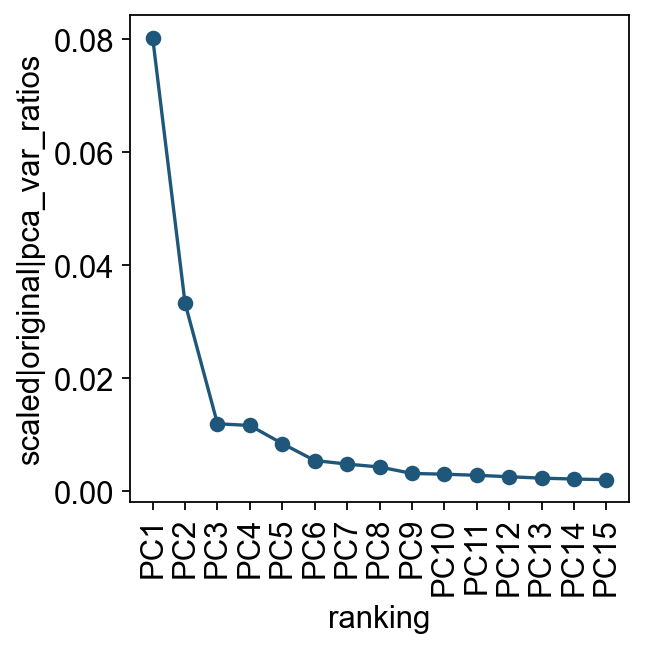

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


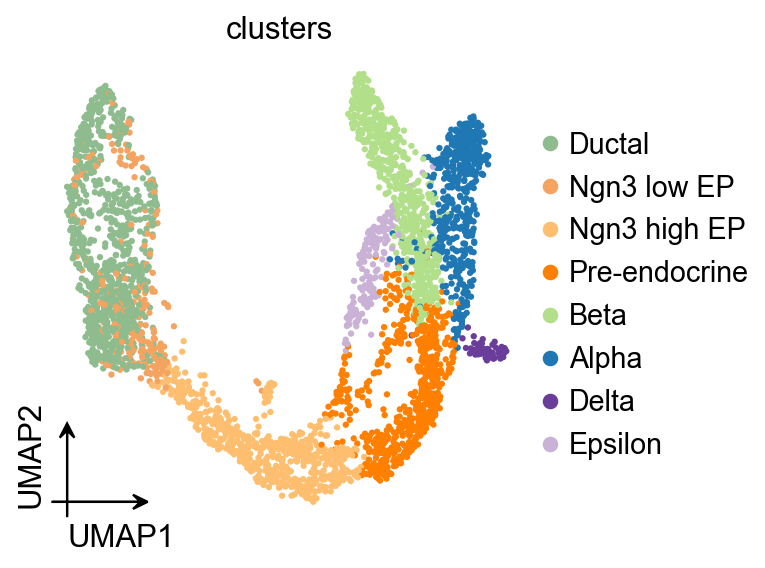

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Slingshot

Slingshot 用于在低维空间中推断连续且可分支的 lineage 结构。它最初面向单细胞 RNA 测序数据中的发育轨迹建模，通常接在降维和聚类之后使用。它可以处理任意数量的分支事件，也允许通过半监督图构建的方式引入先验知识。

In [6]:
Traj=ov.single.TrajInfer(
    adata,basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.set_origin_cells('Ductal')
#Traj.set_terminal_cells(["Granule mature","OL","Astrocytes"])

如果只需要建议的伪时间排序，而暂时不需要检查 lineage 过程，可以不设置 `debug_axes` 参数。

In [7]:
Traj.inference(method='slingshot',num_epochs=1)

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ba03b90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae3ae50>]


Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x14b5c9690>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae3be50>]


Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x14b5c9690>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae3be50>]


Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ba03b90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae3ae50>]


如果希望可视化 lineage 拟合过程，可以设置 `debug_axes`。

Lineages: [Lineage[3, 6, 5, 7, 1, 0], Lineage[3, 6, 5, 7, 1, 4], Lineage[3, 6, 5, 7, 2]]


  0%|          | 0/1 [00:00<?, ?it/s]

Reversing from leaf to root
Averaging branch @1 with lineages: [0, 1] [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ade0a90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae1af90>]


Averaging branch @7 with lineages: [0, 1, 2] [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ac3d510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae83390>]


Shrinking branch @7 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ac3d510>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae83390>]


Shrinking branch @1 with curves: [<pcurvepy2.pcurve.PrincipalCurve object at 0x14ade0a90>, <pcurvepy2.pcurve.PrincipalCurve object at 0x14ae1af90>]


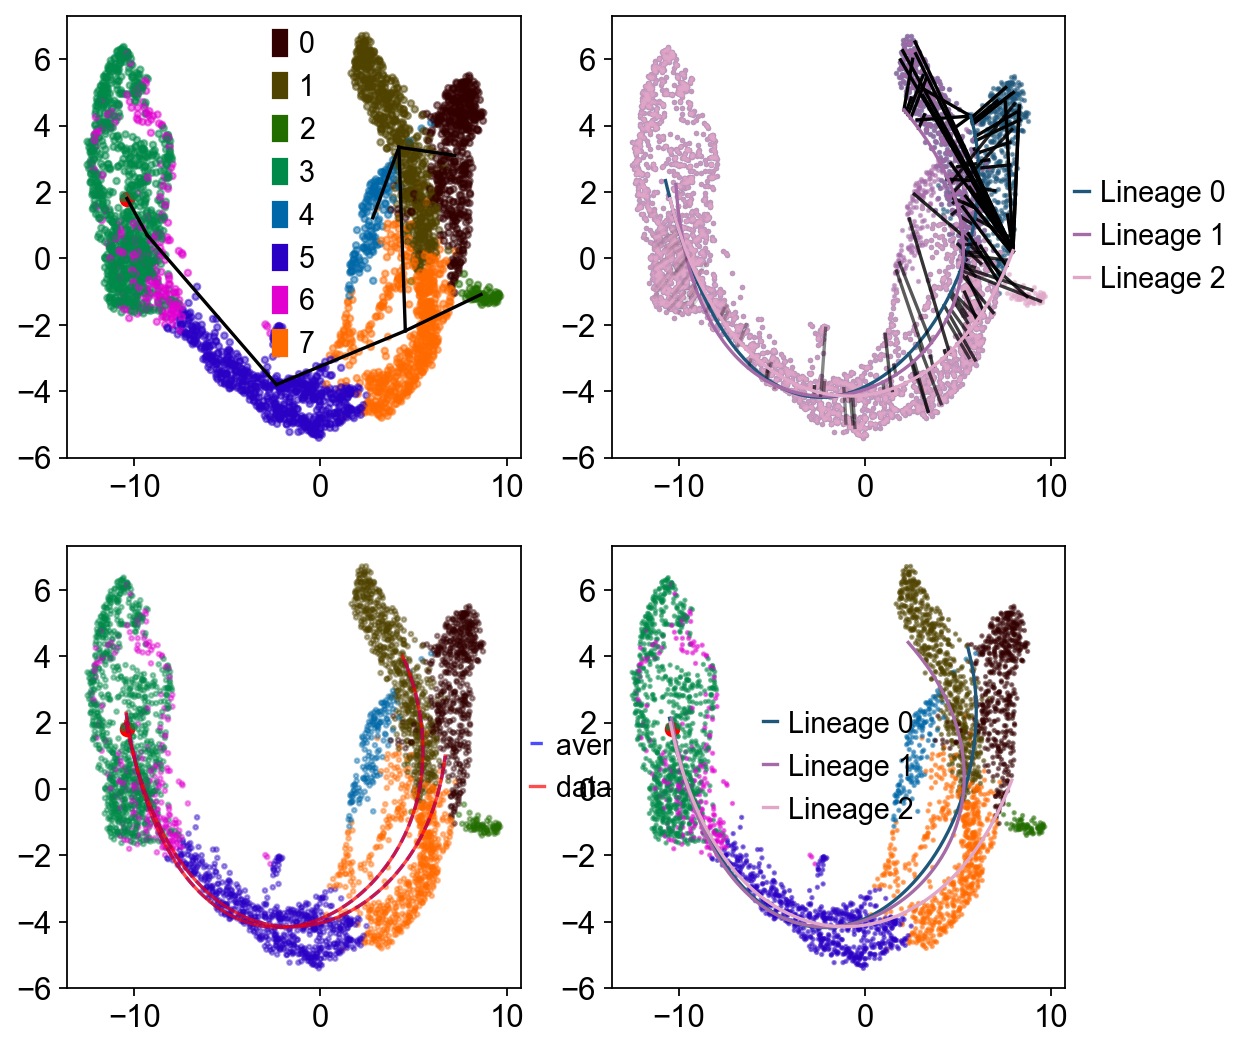

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
Traj.inference(method='slingshot',num_epochs=1,debug_axes=axes)

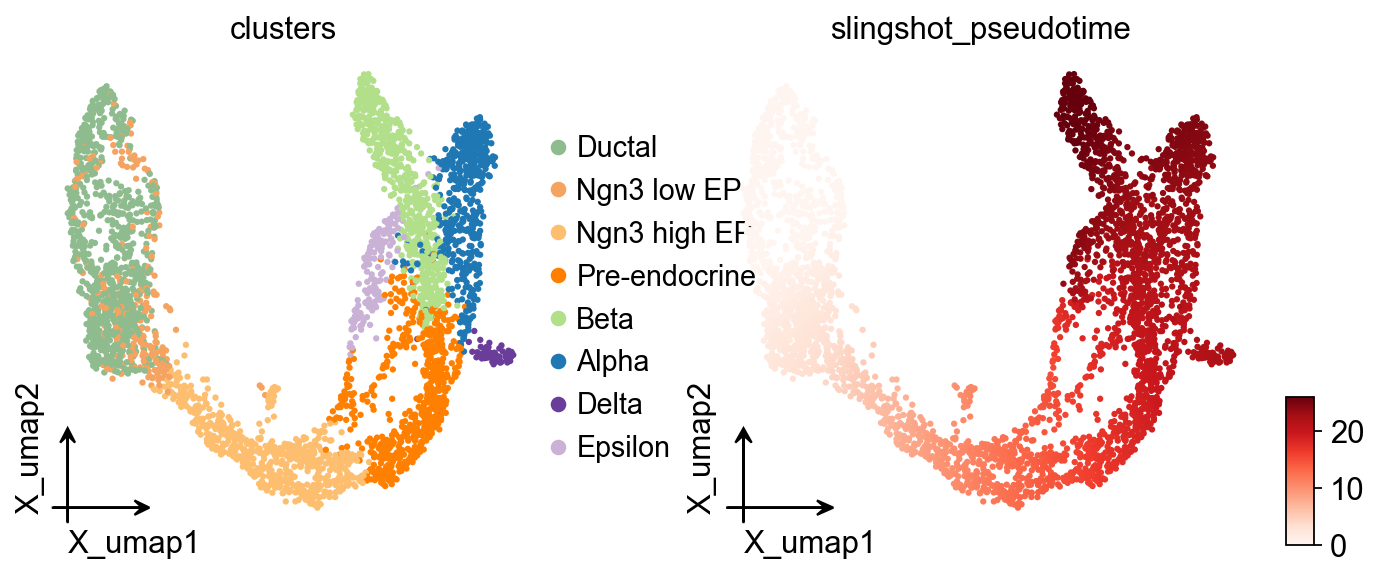

In [9]:
ov.pl.embedding(
    adata,basis='X_umap',
    color=['clusters','slingshot_pseudotime'],
    frameon='small',
    cmap='Reds'
)

In [10]:
sc.pp.neighbors(adata,use_rep='scaled|original|X_pca')
ov.utils.cal_paga(
    adata,
    use_time_prior='slingshot_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['slingshot_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA Slingshot-graph'}>

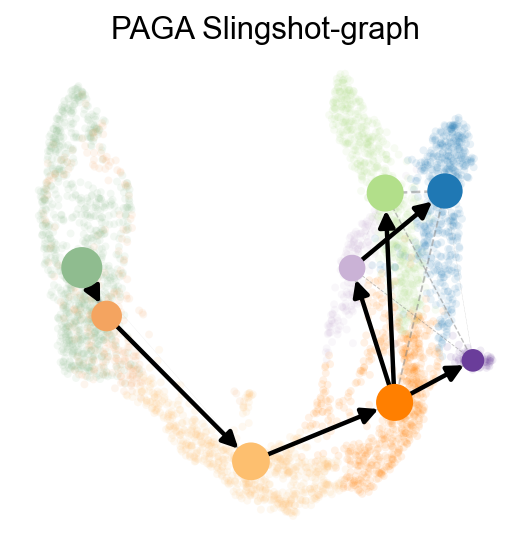

In [11]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA Slingshot-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)

### 用镜像动态热图概括两条 Slingshot lineage

Slingshot 可以返回多条 lineage 曲线。下面的代码会把拟合曲线转换成每个细胞的 lineage 标签和 lineage-specific pseudotime，然后并排绘制两条 lineage。这里反转第一条 lineage，使左侧面板指向分支点，这样更容易比较分支特异性程序。


In [12]:
import pandas as pd
import numpy as np

slingshot_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

n_lineages = len(Traj.slingshot.lineages)
slingshot_lineage_labels = [f'Lineage {i}' for i in range(n_lineages)]

dominant_lineage = np.asarray(Traj.slingshot.cell_weights).argmax(axis=1)
lineage_specific_pt = np.full(adata.n_obs, np.nan)

for i, curve in enumerate(Traj.slingshot.curves):
    curve_pt = np.asarray(curve.pseudotimes_interp, dtype=float)
    adata.obs[f'slingshot_lineage_{i + 1}_pt'] = curve_pt
    lineage_specific_pt[dominant_lineage == i] = curve_pt[dominant_lineage == i]

adata.obs['slingshot_lineage'] = pd.Categorical(
    [slingshot_lineage_labels[i] for i in dominant_lineage],
    categories=slingshot_lineage_labels,
    ordered=True,
)
adata.obs['slingshot_lineage_pseudotime'] = lineage_specific_pt

selected_slingshot_lineages = slingshot_lineage_labels[:2]


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=200 | cmap=RdBu_r
   Lineages: Lineage 0, Lineage 1



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 337 columns


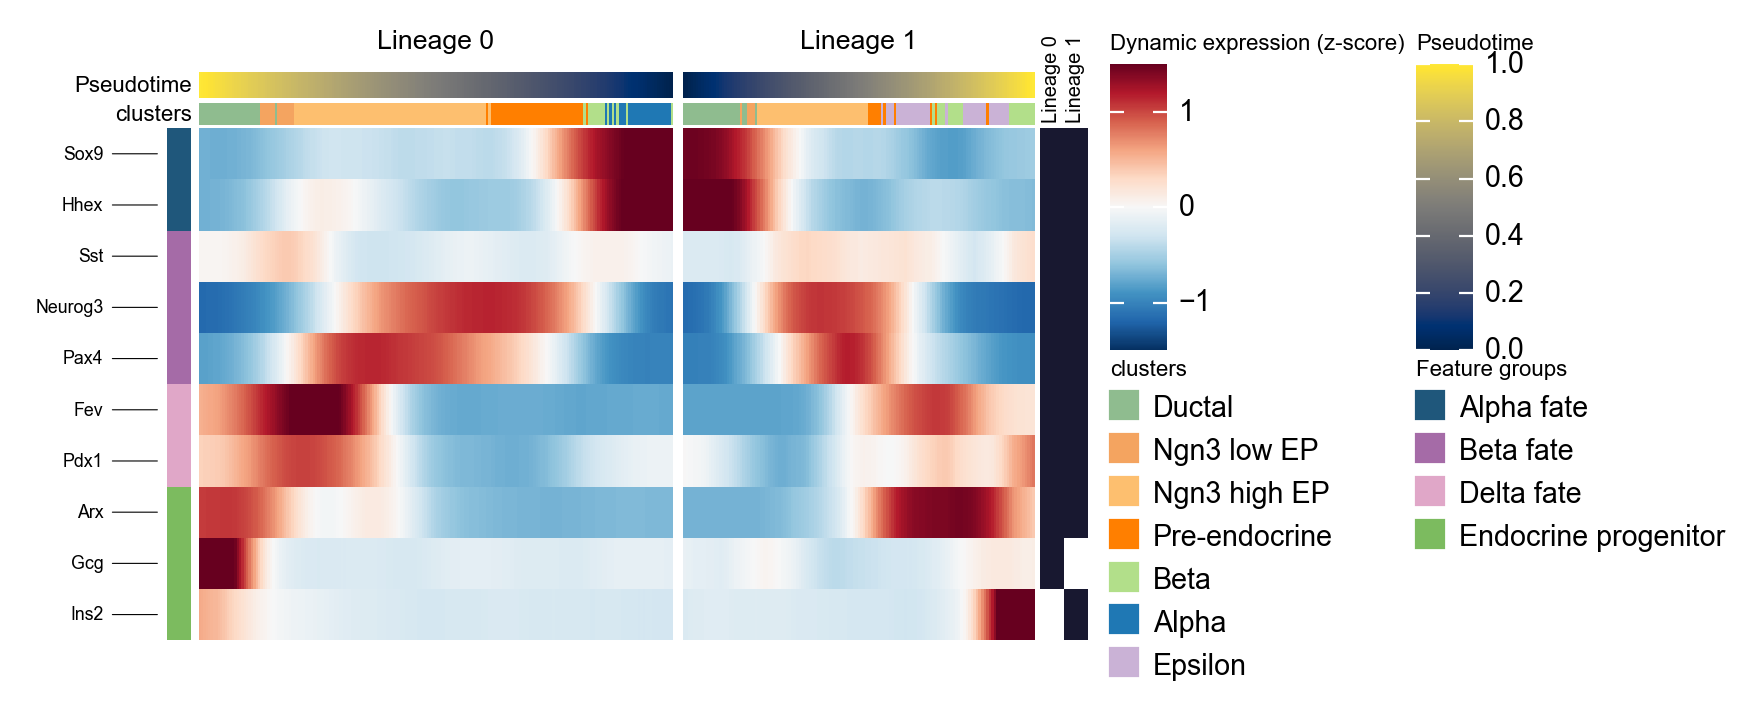

In [13]:
slingshot_marker = {
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
}

d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=200,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)


🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=False | cell_bins=100 | cmap=viridis


   Lineages: Lineage 0, Lineage 1

✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 183 columns


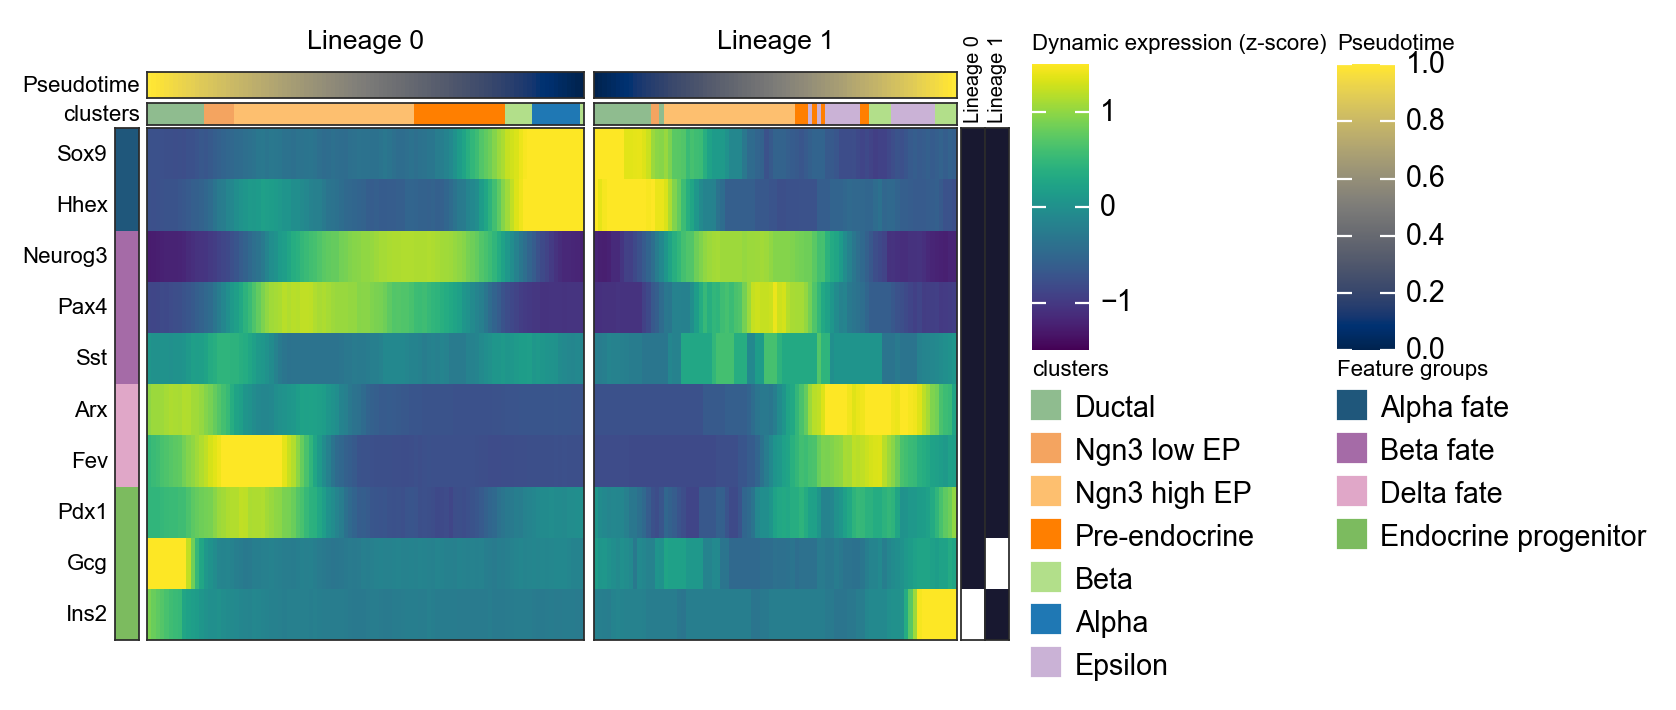

In [14]:
d1 = ov.pl.dynamic_heatmap(
    adata,
    var_names=slingshot_marker,
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    figsize=(5, 4),
    standard_scale='var',
    show_row_names=True,
    use_fitted=False,
    border=True,
    show=False,
)

## 分支感知的伪时间流图

`ov.pl.branch_streamplot` 只需要伪时间和细胞状态标签，因此也可以用于这个轨迹推断方法。图中 ribbon 的宽度表示某类细胞在伪时间上的富集位置，分叉的中心线则帮助观察不同 endocrine fate 在何处展开。


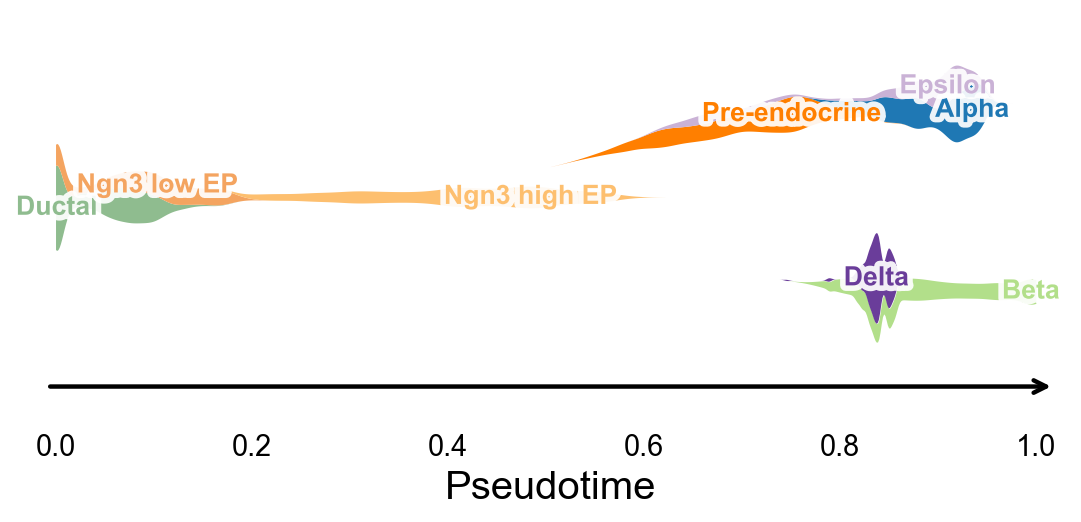

In [15]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='slingshot_pseudotime',
    show=False,
)
plt.show()


### 在 Slingshot lineage 上使用 `dynamic_features` / `dynamic_trends`

这里我们展示两种互补视角。第一种是全局趋势图：沿 `slingshot_pseudotime` 拟合 marker 曲线，并用 cluster 给原始散点着色。第二种是分支趋势图：按 Slingshot lineage 重新拟合，并在 endocrine split 之后比较各 lineage 的差异。

In [16]:
slingshot_trend_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

slingshot_global_dyn = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)



🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: slingshot_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

这张图为每个基因只拟合一条全局趋势线，同时用细胞注释给原始散点着色。它适合区分“整体伪时间表达趋势”和“哪些细胞状态贡献了这些散点”。



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


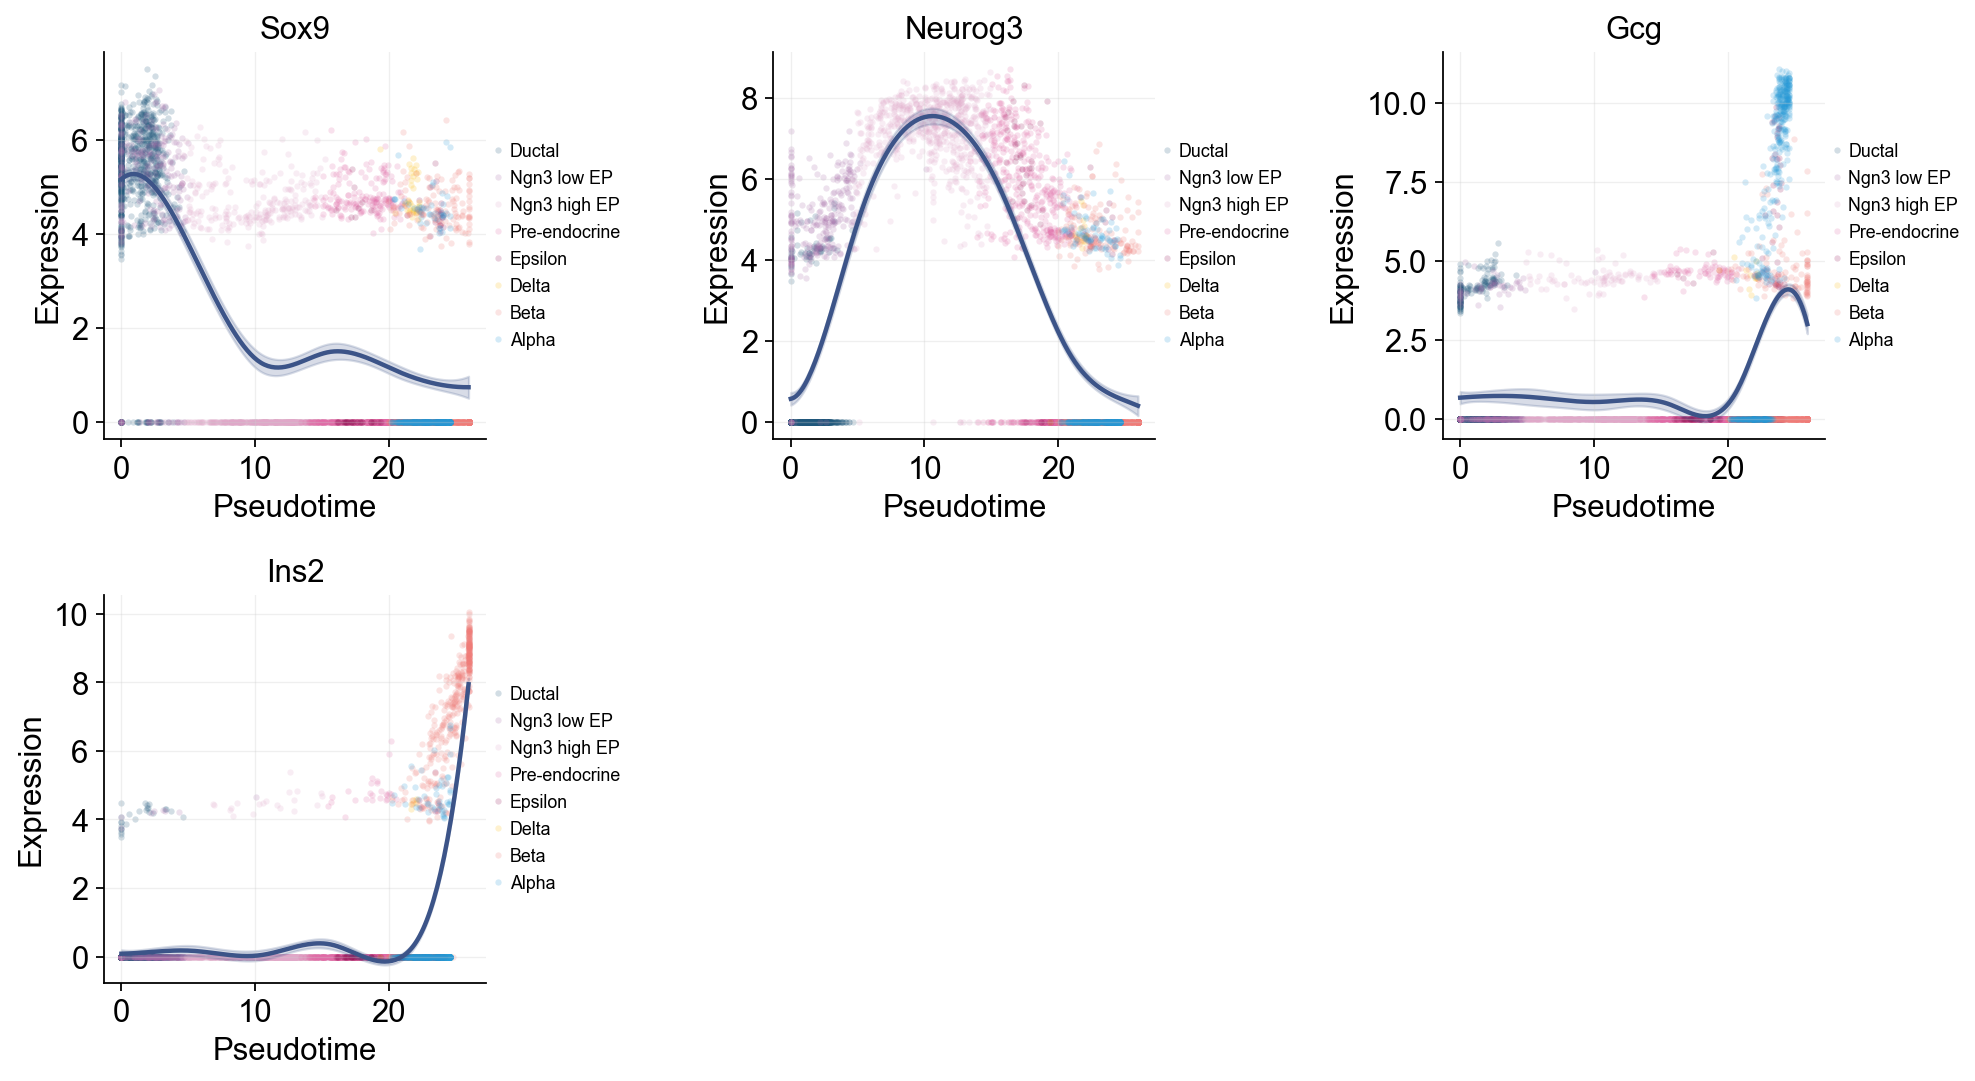

✅ Dynamic trend plotting completed!


In [17]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()


### 多标记基因趋势比较

这里把多个 marker 的拟合曲线叠加在同一伪时间坐标中，方便直接比较不同程序的启动和衰减顺序。



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


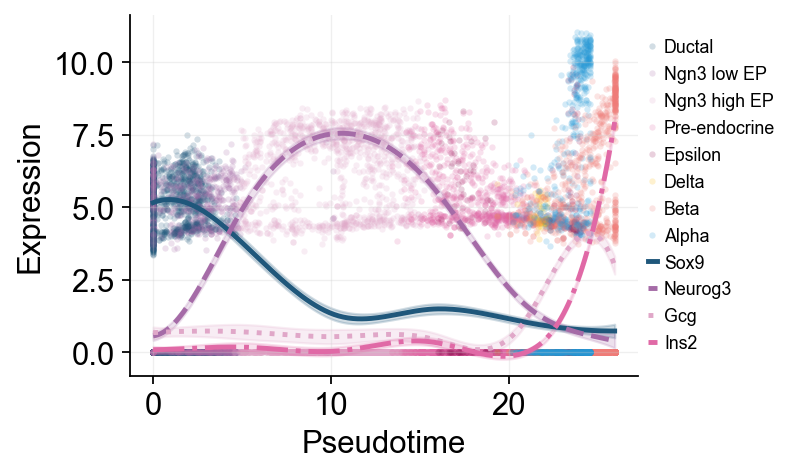

✅ Dynamic trend plotting completed!


In [18]:
ov.pl.dynamic_trends(
    slingshot_global_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6.2, 3.2),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()


In [19]:
slingshot_dyn_res = ov.single.dynamic_features(
    adata,
    genes=slingshot_trend_genes,
    pseudotime='slingshot_lineage_pseudotime',
    groupby='slingshot_lineage',
    groups=selected_slingshot_lineages,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)

slingshot_dyn_res.get_stats(successful_only=True).sort_values(['gene']).head(8)


🔍 Dynamic feature analysis:
   Views: 2 | Features: 10
   Pseudotime: slingshot_lineage_pseudotime
   Grouping: slingshot_lineage
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/20 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 20/20
   ✓ Fitted rows: 4000
   ✓ Raw observations stored: 30550


      dataset        groupby_key      group  gene  success error  n_cells  \
14  Lineage 1  slingshot_lineage  Lineage 1   Arx     True  None      533   
4   Lineage 0  slingshot_lineage  Lineage 0   Arx     True  None     2522   
2   Lineage 0  slingshot_lineage  Lineage 0   Fev     True  None     2522   
12  Lineage 1  slingshot_lineage  Lineage 1   Fev     True  None      533   
3   Lineage 0  slingshot_lineage  Lineage 0   Gcg     True  None     2522   
13  Lineage 1  slingshot_lineage  Lineage 1   Gcg     True  None      533   
9   Lineage 0  slingshot_lineage  Lineage 0  Hhex     True  None     2522   
19  Lineage 1  slingshot_lineage  Lineage 1  Hhex     True  None      533   

    exp_ncells  peak_time  valley_time  min_pseudotime  max_pseudotime  \
14         110  20.163205     8.026130             0.0       25.970730   
4          600  22.561005     7.726371             0.0       24.600767   
2         1010  19.594078     9.086213             0.0       24.600767   
12        


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=False | compare_groups=True


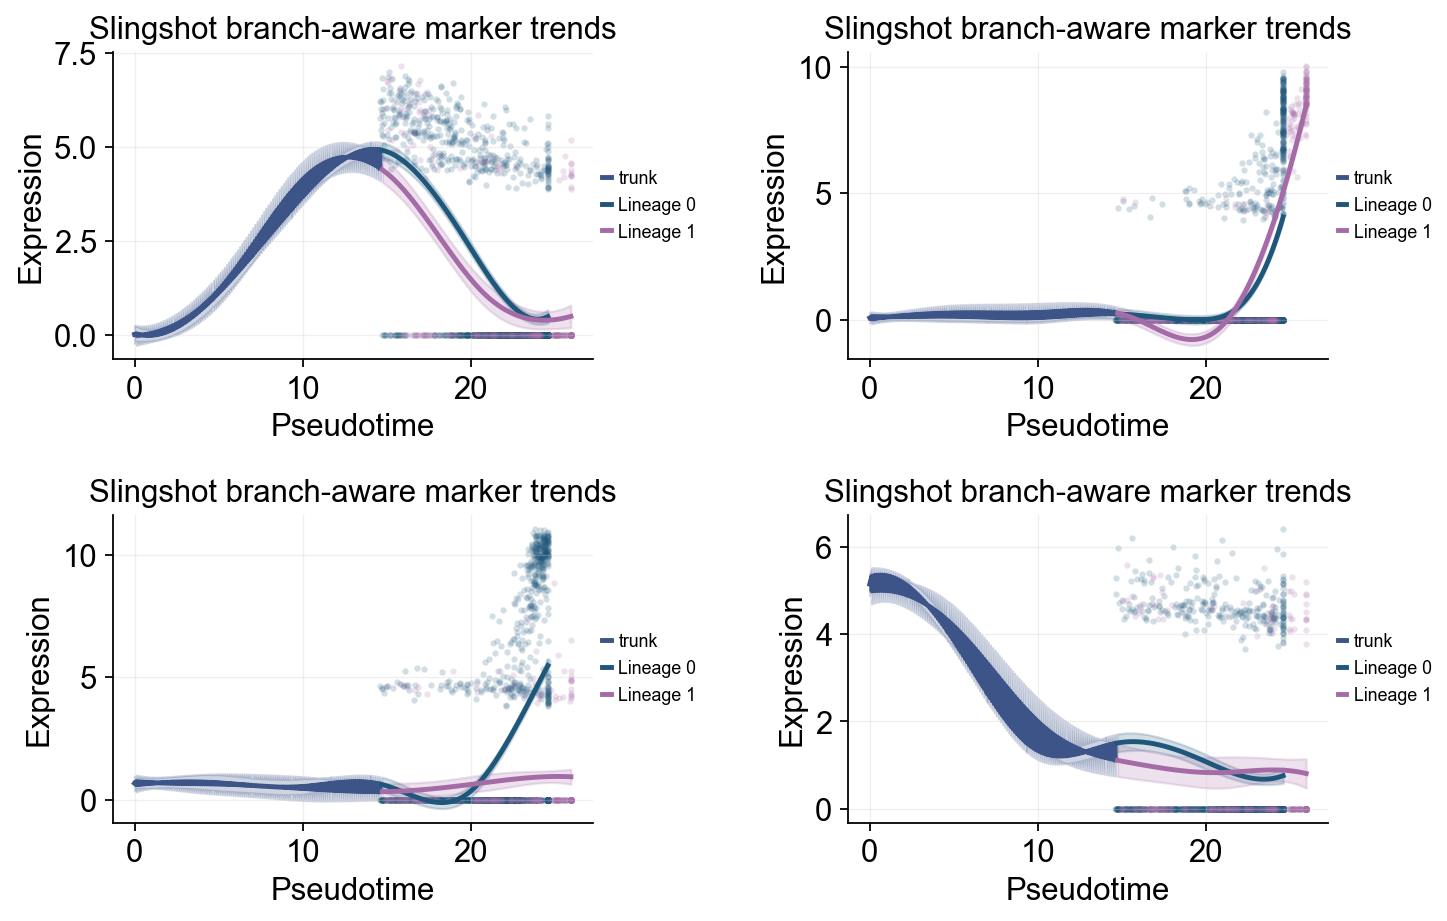

✅ Dynamic trend plotting completed!


In [20]:
slingshot_split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])
slingshot_split_time = float(np.nanmedian(adata.obs.loc[slingshot_split_mask, 'slingshot_lineage_pseudotime'])) if slingshot_split_mask.any() else float(np.nanmedian(adata.obs['slingshot_lineage_pseudotime']))

ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_groups=True,
    split_time=slingshot_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(5.5, 3),
    linewidth=2.2,
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Slingshot branch-aware marker trends',
)
plt.show()


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 2
   compare_features=True | compare_groups=True


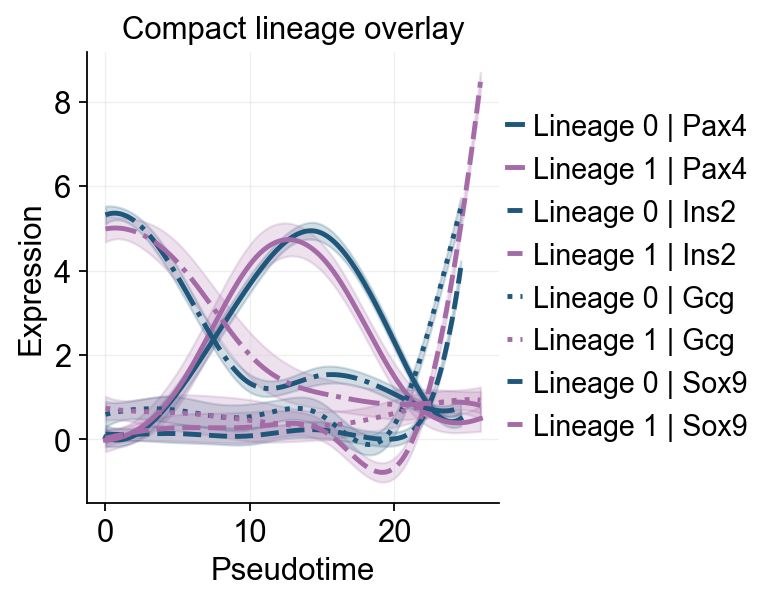

✅ Dynamic trend plotting completed!


In [21]:
ov.pl.dynamic_trends(
    slingshot_dyn_res,
    genes=['Pax4', 'Ins2', 'Gcg', 'Sox9'],
    compare_features=True,
    compare_groups=True,
    line_style_by='features',
    figsize=(6, 4),
    linewidth=2.2,
    title='Compact lineage overlay',
)
plt.show()


🔍 Dynamic heatmap:
   Candidate features: 3000
   Pseudotime: slingshot_lineage_pseudotime
   Lineage key: slingshot_lineage
   Cell annotation: clusters
   use_fitted=True | cell_bins=90 | cmap=viridis


   Lineages: Lineage 0, Lineage 1



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 1000 features × 166 columns


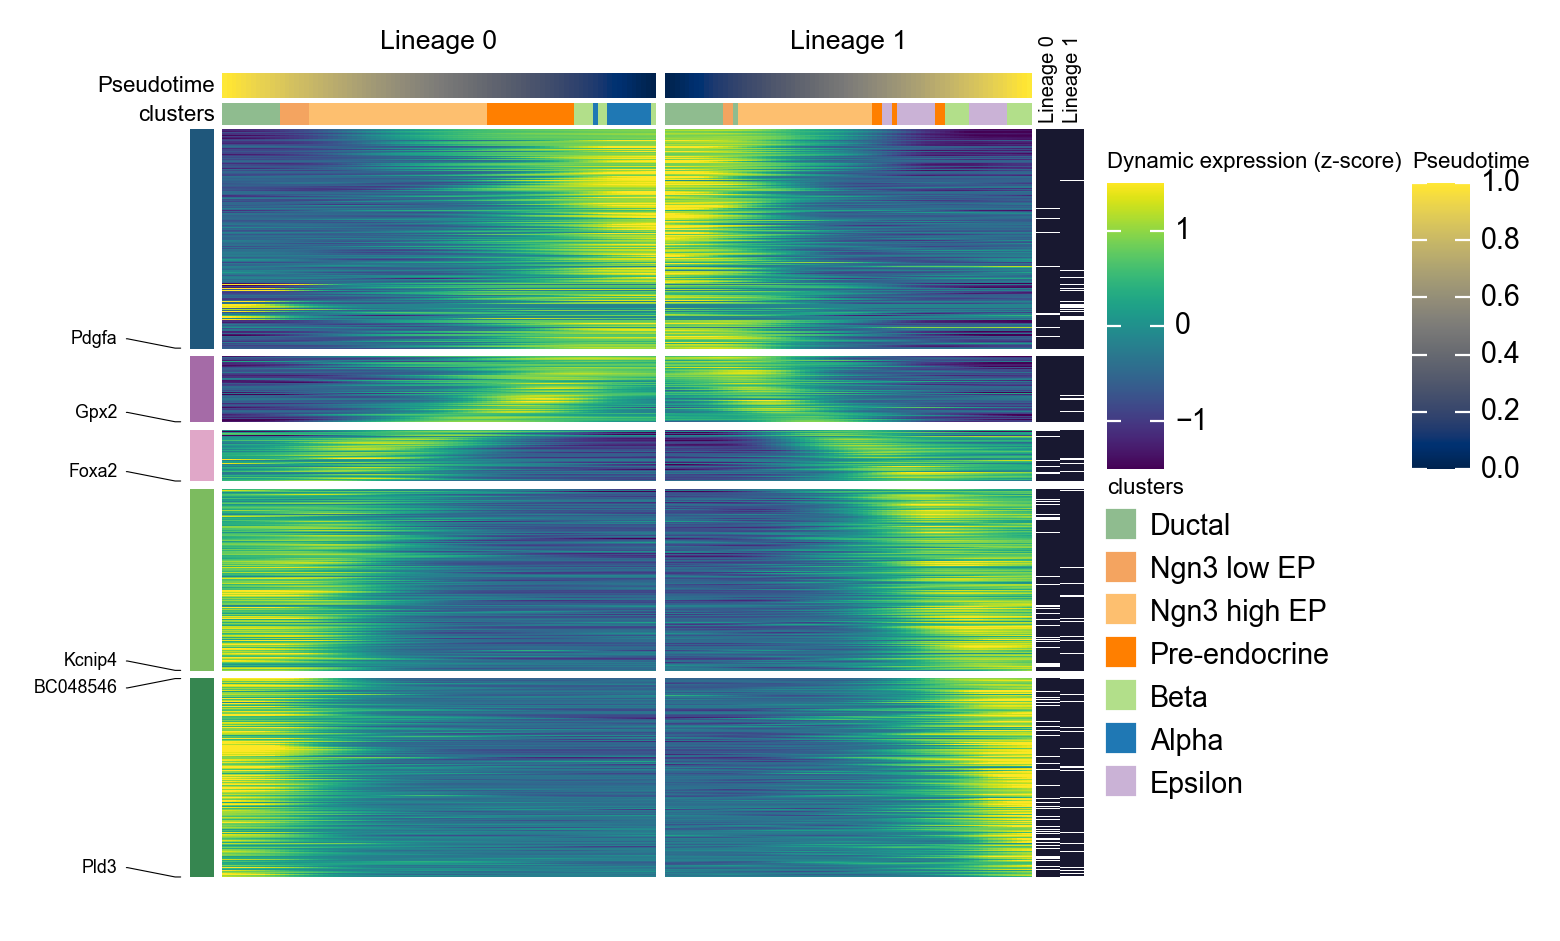

In [22]:
g = ov.pl.dynamic_heatmap(
    adata,
    top_features=1000,       # 保留动态性最强的前 1000 个基因用于绘图
    pseudotime='slingshot_lineage_pseudotime',
    lineage_key='slingshot_lineage',
    lineages=selected_slingshot_lineages,
    reverse_ht=[selected_slingshot_lineages[0]],
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=90,
    smooth_window=17,
    fitted_window=31,
    n_split=5,
    figsize=(5, 6),
    standard_scale='var',
    cmap='viridis',
    top_label_features=10,
    border=False,
    show=False,
)